 ِAbdullah Aldali  && Rima merai

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded successfully ✓")


Libraries loaded successfully ✓


## 2. Load & Explore the MNIST Dataset

In [2]:
# Load the pre-split dataset
X_train_raw = np.load('X_train.npy')
X_test_raw  = np.load('X_test.npy')
y_train      = np.load('y_train.npy')
y_test       = np.load('y_test.npy')

print(f"Training set : X={X_train_raw.shape}, y={y_train.shape}")
print(f"Test set     : X={X_test_raw.shape},  y={y_test.shape}")
print(f"Pixel range  : [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Classes      : {np.unique(y_train)}")


Training set : X=(60000, 28, 28), y=(60000,)
Test set     : X=(10000, 28, 28),  y=(10000,)
Pixel range  : [0, 255]
Classes      : [0 1 2 3 4 5 6 7 8 9]


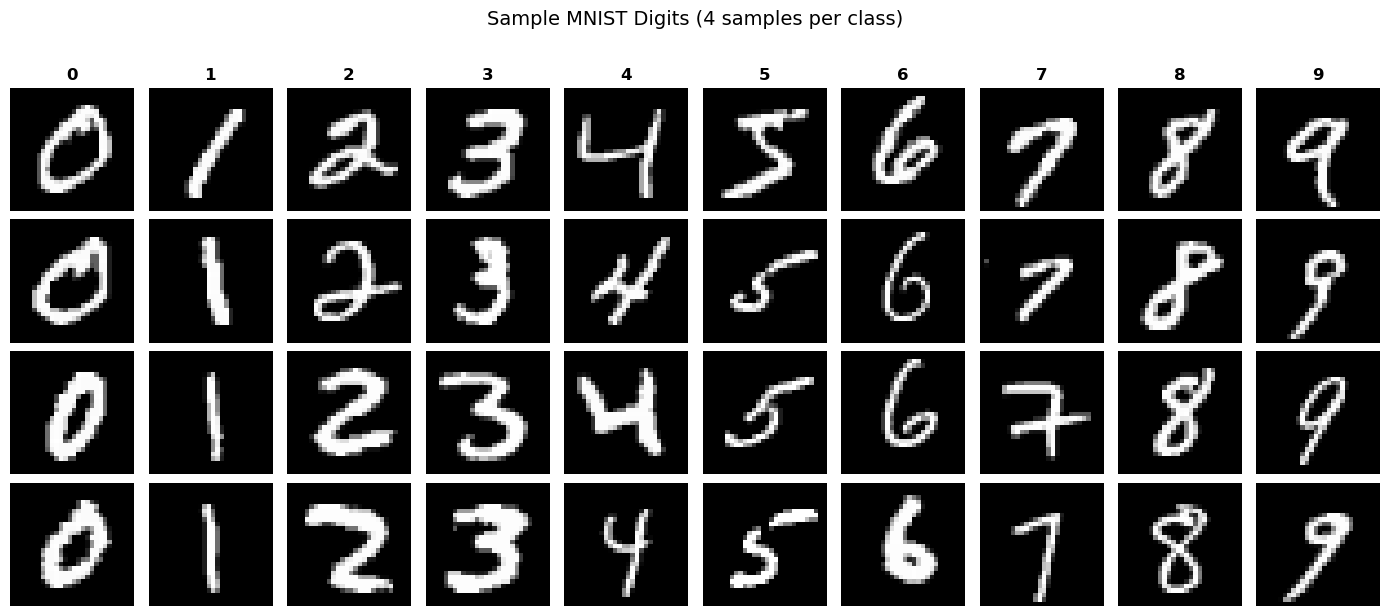

In [3]:
# Visualise sample digits
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
for digit in range(10):
    indices = np.where(y_train == digit)[0][:4]
    for row, idx in enumerate(indices):
        axes[row, digit].imshow(X_train_raw[idx], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=12, fontweight='bold')
plt.suptitle('Sample MNIST Digits (4 samples per class)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Preprocessing

In [4]:
# Flatten 28x28 → 784 and normalise to [0, 1]
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1).astype(np.float64) / 255.0
X_test  = X_test_raw.reshape(X_test_raw.shape[0],  -1).astype(np.float64) / 255.0

print(f"Flattened shape : {X_train.shape}")
print(f"Pixel range     : [{X_train.min():.1f}, {X_train.max():.1f}]")

# One-hot encode labels (needed for from-scratch backprop)
def one_hot(y, num_classes=10):
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

y_train_oh = one_hot(y_train)
y_test_oh  = one_hot(y_test)
print(f"One-hot label shape: {y_train_oh.shape}")


Flattened shape : (60000, 784)
Pixel range     : [0.0, 1.0]
One-hot label shape: (60000, 10)


## 4. Model 1 — Multi-Layer Perceptron from Scratch
### Architecture: Input(784) → Hidden1 → Hidden2 → Output(10)



In [5]:
# ── Activation Functions ─────────────────────────────────────────────────────
def relu(z):    return np.maximum(0, z)
def relu_d(z):  return (z > 0).astype(float)

def sigmoid(z): return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
def sigmoid_d(z): s = sigmoid(z); return s * (1 - s)

def tanh_act(z):   return np.tanh(z)
def tanh_d(z):     return 1.0 - np.tanh(z)**2

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

print("Activation functions defined ✓")


Activation functions defined ✓


In [6]:
# ── MLP Class (From Scratch) ──────────────────────────────────────────────────
class MLP:


    def __init__(self, layer_sizes, hidden_act='relu', lr=0.01, seed=42):
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.hidden_act = hidden_act
        self.weights, self.biases = [], []

        # Weight initialisation: He for ReLU, Xavier for others
        for i in range(len(layer_sizes) - 1):
            scale = (np.sqrt(2.0 / layer_sizes[i]) if hidden_act == 'relu'
                     else np.sqrt(1.0 / layer_sizes[i]))
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * scale)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))

    # ── Helpers ──────────────────────────────────────────────────────────────
    def _activate(self, z, output_layer=False):
        if output_layer:
            return softmax(z)
        return {'relu': relu, 'sigmoid': sigmoid, 'tanh': tanh_act}[self.hidden_act](z)

    def _activate_deriv(self, z):
        return {'relu': relu_d, 'sigmoid': sigmoid_d, 'tanh': tanh_d}[self.hidden_act](z)

    # ── Forward Pass ─────────────────────────────────────────────────────────
    def forward(self, X):
        self.zs, self.activations = [], [X]
        a = X
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            z = a @ w + b
            self.zs.append(z)
            a = self._activate(z, output_layer=(i == len(self.weights) - 1))
            self.activations.append(a)
        return self.activations[-1]

    # ── Backward Pass (Backpropagation) ──────────────────────────────────────
    def backward(self, y_true):
        m = y_true.shape[0]
        # Gradient of cross-entropy + softmax (combined)
        delta = self.activations[-1] - y_true
        grads_w, grads_b = [], []

        for i in reversed(range(len(self.weights))):
            dw = self.activations[i].T @ delta / m
            db = delta.mean(axis=0, keepdims=True)
            grads_w.insert(0, dw)
            grads_b.insert(0, db)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self._activate_deriv(self.zs[i-1])

        # Gradient descent update
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * grads_w[i]
            self.biases[i]  -= self.lr * grads_b[i]

    # ── Training Loop ────────────────────────────────────────────────────────
    def fit(self, X, y, epochs=20, batch_size=256, X_val=None, y_val=None, verbose=True):
        history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
        m = X.shape[0]

        for ep in range(epochs):
            # Shuffle data each epoch
            idx = np.random.permutation(m)
            X_s, y_s = X[idx], y[idx]
            ep_loss = 0.0

            for j in range(0, m, batch_size):
                Xb, yb = X_s[j:j+batch_size], y_s[j:j+batch_size]
                out     = self.forward(Xb)
                ep_loss += cross_entropy_loss(out, yb) * len(Xb)
                self.backward(yb)

            ep_loss /= m
            train_preds = self.forward(X)
            train_acc   = np.mean(train_preds.argmax(1) == y.argmax(1))
            history['loss'].append(ep_loss)
            history['acc'].append(train_acc)

            if X_val is not None:
                val_preds = self.forward(X_val)
                val_loss  = cross_entropy_loss(val_preds, y_val)
                val_acc   = np.mean(val_preds.argmax(1) == y_val.argmax(1))
                history['val_loss'].append(val_loss)
                history['val_acc'].append(val_acc)

            if verbose and (ep + 1) % 5 == 0:
                msg = (f"  Epoch {ep+1:2d}/{epochs} — loss: {ep_loss:.4f} "
                       f"— train_acc: {train_acc:.4f}")
                if X_val is not None:
                    msg += f" — val_acc: {val_acc:.4f}"
                print(msg)

        return history

    # ── Inference ────────────────────────────────────────────────────────────
    def predict(self, X):      return self.forward(X).argmax(axis=1)
    def score(self, X, y_int): return np.mean(self.predict(X) == y_int)

print("MLP class defined ✓")


MLP class defined ✓


### Experiment 1 — Comparing Activation Functions
Architecture: 784 → 128 → 64 → 10 | Epochs: 20 | Batch size: 256


In [7]:
experiment_results = {}

# ── ReLU ─────────────────────────────────────────────────────────────────────
print("=" * 55)
print("Experiment 1a: ReLU activation, lr=0.1")
print("=" * 55)
mlp_relu = MLP([784, 128, 64, 10], hidden_act='relu', lr=0.1, seed=42)
hist_relu = mlp_relu.fit(X_train, y_train_oh, epochs=20, batch_size=256,
                         X_val=X_test, y_val=y_test_oh)
acc_relu = mlp_relu.score(X_test, y_test)
experiment_results['ReLU (128-64)'] = acc_relu
print(f"  >>> Test Accuracy: {acc_relu:.4f} ({acc_relu*100:.2f}%)")


Experiment 1a: ReLU activation, lr=0.1
  Epoch  5/20 — loss: 0.1535 — train_acc: 0.9579 — val_acc: 0.9548
  Epoch 10/20 — loss: 0.0920 — train_acc: 0.9755 — val_acc: 0.9681
  Epoch 15/20 — loss: 0.0636 — train_acc: 0.9841 — val_acc: 0.9734
  Epoch 20/20 — loss: 0.0460 — train_acc: 0.9892 — val_acc: 0.9771
  >>> Test Accuracy: 0.9771 (97.71%)


In [9]:
# ── Sigmoid ──────────────────────────────────────────────────────────────────
print("=" * 55)
print("Experiment 1b: Sigmoid activation, lr=0.5")
print("=" * 55)
mlp_sig = MLP([784, 128, 64, 10], hidden_act='sigmoid', lr=0.5, seed=42)
hist_sig = mlp_sig.fit(X_train, y_train_oh, epochs=20, batch_size=256,
                       X_val=X_test, y_val=y_test_oh)
acc_sig = mlp_sig.score(X_test, y_test)
experiment_results['Sigmoid (128-64)'] = acc_sig
print(f"  >>> Test Accuracy: {acc_sig:.4f} ({acc_sig*100:.2f}%)")


Experiment 1b: Sigmoid activation, lr=0.5
  Epoch  5/20 — loss: 0.2761 — train_acc: 0.9224 — val_acc: 0.9228
  Epoch 10/20 — loss: 0.1774 — train_acc: 0.9520 — val_acc: 0.9497
  Epoch 15/20 — loss: 0.1264 — train_acc: 0.9658 — val_acc: 0.9620
  Epoch 20/20 — loss: 0.0955 — train_acc: 0.9713 — val_acc: 0.9660
  >>> Test Accuracy: 0.9660 (96.60%)


In [10]:
# ── Tanh ─────────────────────────────────────────────────────────────────────
print("=" * 55)
print("Experiment 1c: Tanh activation, lr=0.1")
print("=" * 55)
mlp_tanh = MLP([784, 128, 64, 10], hidden_act='tanh', lr=0.1, seed=42)
hist_tanh = mlp_tanh.fit(X_train, y_train_oh, epochs=20, batch_size=256,
                         X_val=X_test, y_val=y_test_oh)
acc_tanh = mlp_tanh.score(X_test, y_test)
experiment_results['Tanh (128-64)'] = acc_tanh
print(f"  >>> Test Accuracy: {acc_tanh:.4f} ({acc_tanh*100:.2f}%)")


Experiment 1c: Tanh activation, lr=0.1
  Epoch  5/20 — loss: 0.2190 — train_acc: 0.9404 — val_acc: 0.9400
  Epoch 10/20 — loss: 0.1399 — train_acc: 0.9626 — val_acc: 0.9570
  Epoch 15/20 — loss: 0.1010 — train_acc: 0.9730 — val_acc: 0.9651
  Epoch 20/20 — loss: 0.0774 — train_acc: 0.9792 — val_acc: 0.9703
  >>> Test Accuracy: 0.9703 (97.03%)


### Experiment 2 — Varying Number of Hidden Neurons

In [11]:
# ── Smaller network ──────────────────────────────────────────────────────────
print("Experiment 2a: Small network 64-32, ReLU, lr=0.1")
mlp_small = MLP([784, 64, 32, 10], hidden_act='relu', lr=0.1, seed=42)
hist_small = mlp_small.fit(X_train, y_train_oh, epochs=20, batch_size=256,
                            X_val=X_test, y_val=y_test_oh, verbose=False)
acc_small = mlp_small.score(X_test, y_test)
experiment_results['ReLU (64-32)'] = acc_small
print(f"  >>> Test Accuracy: {acc_small:.4f}")

# ── Larger network ────────────────────────────────────────────────────────────
print("Experiment 2b: Large network 256-128, ReLU, lr=0.1")
mlp_large = MLP([784, 256, 128, 10], hidden_act='relu', lr=0.1, seed=42)
hist_large = mlp_large.fit(X_train, y_train_oh, epochs=20, batch_size=256,
                            X_val=X_test, y_val=y_test_oh, verbose=False)
acc_large = mlp_large.score(X_test, y_test)
experiment_results['ReLU (256-128)'] = acc_large
print(f"  >>> Test Accuracy: {acc_large:.4f}")


Experiment 2a: Small network 64-32, ReLU, lr=0.1
  >>> Test Accuracy: 0.9716
Experiment 2b: Large network 256-128, ReLU, lr=0.1
  >>> Test Accuracy: 0.9750


### Experiment 3 — Varying Learning Rate (ReLU, 128-64)

In [12]:
for lr_val in [0.01, 0.05, 0.1, 0.5]:
    m = MLP([784, 128, 64, 10], hidden_act='relu', lr=lr_val, seed=42)
    m.fit(X_train, y_train_oh, epochs=20, batch_size=256, verbose=False)
    acc = m.score(X_test, y_test)
    experiment_results[f'ReLU lr={lr_val}'] = acc
    print(f"  lr={lr_val:.2f} → Test Accuracy: {acc:.4f}")


  lr=0.01 → Test Accuracy: 0.9376
  lr=0.05 → Test Accuracy: 0.9704
  lr=0.10 → Test Accuracy: 0.9771
  lr=0.50 → Test Accuracy: 0.9816


### Training & Validation Curves (Best Model 1 Configuration)

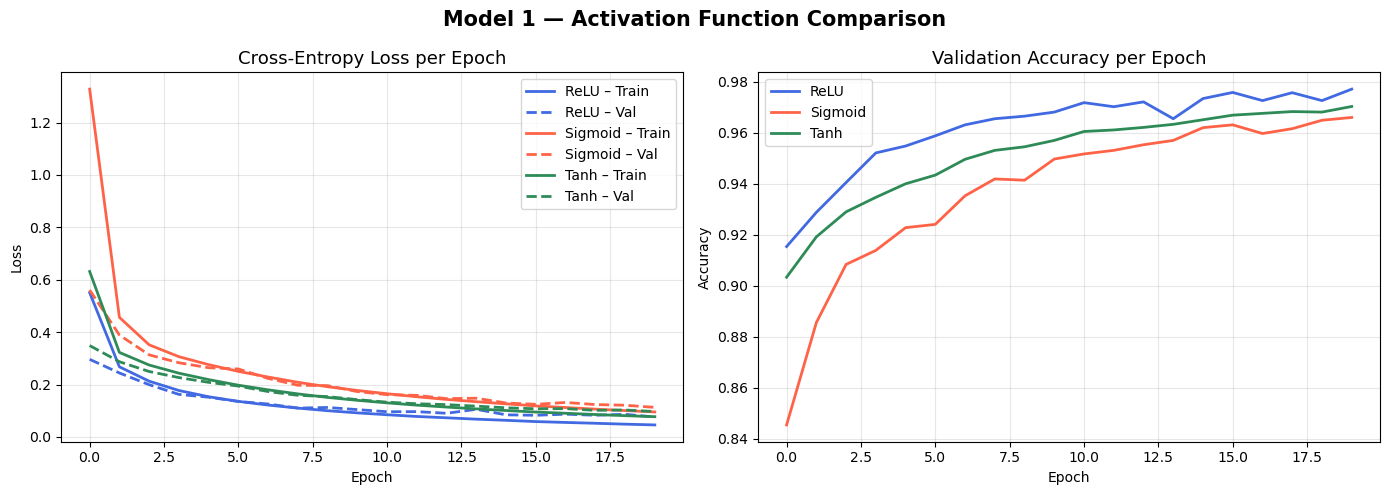

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(hist_relu['loss'],     label='ReLU – Train',    color='royalblue',  lw=2)
axes[0].plot(hist_relu['val_loss'], label='ReLU – Val',      color='royalblue',  lw=2, ls='--')
axes[0].plot(hist_sig['loss'],      label='Sigmoid – Train', color='tomato',     lw=2)
axes[0].plot(hist_sig['val_loss'],  label='Sigmoid – Val',   color='tomato',     lw=2, ls='--')
axes[0].plot(hist_tanh['loss'],     label='Tanh – Train',    color='seagreen',   lw=2)
axes[0].plot(hist_tanh['val_loss'], label='Tanh – Val',      color='seagreen',   lw=2, ls='--')
axes[0].set_title('Cross-Entropy Loss per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(hist_relu['val_acc'],  label='ReLU',    color='royalblue', lw=2)
axes[1].plot(hist_sig['val_acc'],   label='Sigmoid', color='tomato',    lw=2)
axes[1].plot(hist_tanh['val_acc'],  label='Tanh',    color='seagreen',  lw=2)
axes[1].set_title('Validation Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Model 1 — Activation Function Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model1_curves.png', dpi=100, bbox_inches='tight')
plt.show()


### Confusion Matrix — Model 1 Best Configuration (ReLU 128-64)

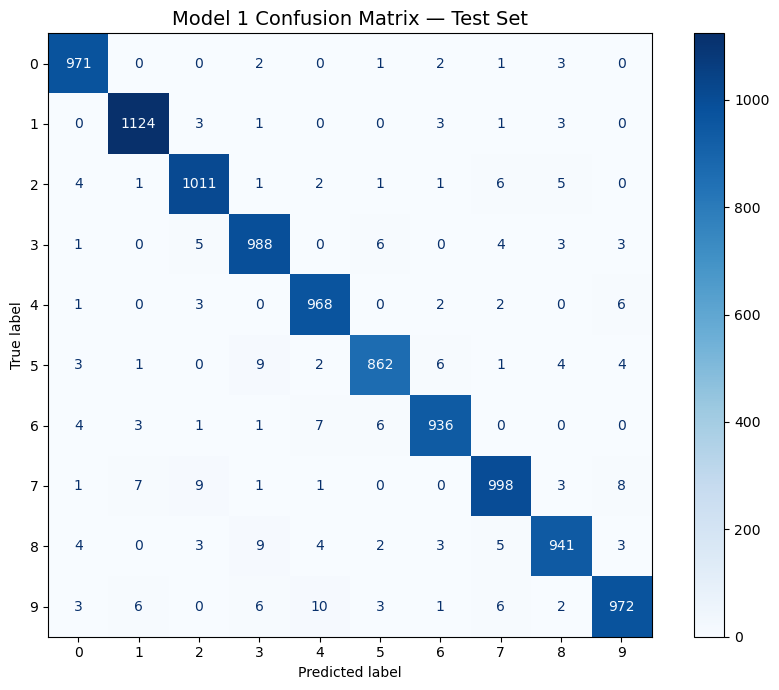


Classification Report — Model 1 (ReLU 128-64):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [14]:
y_pred_m1 = mlp_relu.predict(X_test)
cm = confusion_matrix(y_test, y_pred_m1)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model 1 Confusion Matrix — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('model1_cm.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nClassification Report — Model 1 (ReLU 128-64):")
print(classification_report(y_test, y_pred_m1, target_names=[str(i) for i in range(10)]))


### Model 1 — Experiments Summary

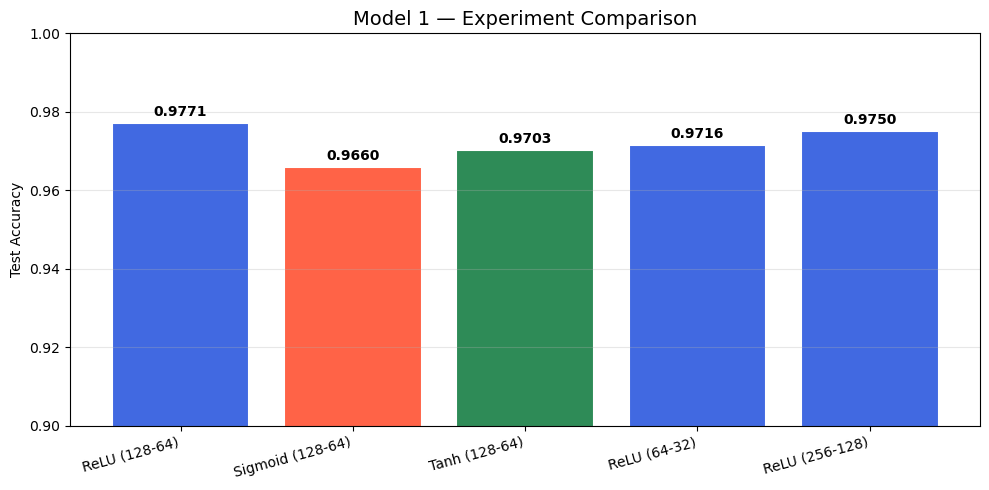


📊 Model 1 Results Summary:
---------------------------------------------
  ReLU (128-64)             → 0.9771 (97.71%)
  Sigmoid (128-64)          → 0.9660 (96.60%)
  Tanh (128-64)             → 0.9703 (97.03%)
  ReLU (64-32)              → 0.9716 (97.16%)
  ReLU (256-128)            → 0.9750 (97.50%)

✅ Best: ReLU (128-64)  →  0.9771


In [15]:
# Filter to the clean activation/architecture experiments
summary_keys = ['ReLU (128-64)', 'Sigmoid (128-64)', 'Tanh (128-64)',
                'ReLU (64-32)', 'ReLU (256-128)']
names = [k for k in summary_keys if k in experiment_results]
accs  = [experiment_results[k] for k in names]

colors = ['royalblue' if 'ReLU' in n else 'tomato' if 'Sigmoid' in n else 'seagreen'
          for n in names]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(0.90, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model 1 — Experiment Comparison', fontsize=14)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model1_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 Model 1 Results Summary:")
print("-" * 45)
for n, a in zip(names, accs):
    print(f"  {n:<25} → {a:.4f} ({a*100:.2f}%)")
best_name = names[np.argmax(accs)]
print(f"\n✅ Best: {best_name}  →  {max(accs):.4f}")


---
## 5. Model 2 — Deep Neural Network (Scikit-learn MLPClassifier)
### Architecture: 784 → 256 → 128 → 64 → 32 → 10
Deeper model with Adam optimizer and more hidden layers.


In [16]:
deep_results = {}

# ── Deep Model — ReLU, Adam ──────────────────────────────────────────────────
print("=" * 60)
print("Deep Model 1: ReLU — 256-128-64-32 — Adam — lr=0.001")
print("=" * 60)
deep_relu = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=256,
    max_iter=30,
    random_state=42,
    verbose=True
)
deep_relu.fit(X_train, y_train)
acc_deep_relu = deep_relu.score(X_test, y_test)
deep_results['Deep ReLU (256-128-64-32)'] = acc_deep_relu
print(f"\n>>> Test Accuracy: {acc_deep_relu:.4f} ({acc_deep_relu*100:.2f}%)")


Deep Model 1: ReLU — 256-128-64-32 — Adam — lr=0.001
Iteration 1, loss = 0.42967562
Iteration 2, loss = 0.13547336
Iteration 3, loss = 0.09241770
Iteration 4, loss = 0.06892888
Iteration 5, loss = 0.05146614
Iteration 6, loss = 0.03975225
Iteration 7, loss = 0.02965384
Iteration 8, loss = 0.02594635
Iteration 9, loss = 0.01998536
Iteration 10, loss = 0.01885871
Iteration 11, loss = 0.01716631
Iteration 12, loss = 0.01384111
Iteration 13, loss = 0.01240025
Iteration 14, loss = 0.01020001
Iteration 15, loss = 0.00866476
Iteration 16, loss = 0.01609729
Iteration 17, loss = 0.00807037
Iteration 18, loss = 0.00955476
Iteration 19, loss = 0.01059605
Iteration 20, loss = 0.00736904
Iteration 21, loss = 0.00771297
Iteration 22, loss = 0.01056221
Iteration 23, loss = 0.00988968
Iteration 24, loss = 0.00584887
Iteration 25, loss = 0.00522128
Iteration 26, loss = 0.01170400
Iteration 27, loss = 0.00394496
Iteration 28, loss = 0.00751195
Iteration 29, loss = 0.00577766
Iteration 30, loss = 0.00403

In [17]:
# ── Deep Model — Tanh ────────────────────────────────────────────────────────
print("=" * 60)
print("Deep Model 2: Tanh — 256-128-64-32 — Adam — lr=0.001")
print("=" * 60)
deep_tanh = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=256,
    max_iter=30,
    random_state=42,
    verbose=True
)
deep_tanh.fit(X_train, y_train)
acc_deep_tanh = deep_tanh.score(X_test, y_test)
deep_results['Deep Tanh (256-128-64-32)'] = acc_deep_tanh
print(f"\n>>> Test Accuracy: {acc_deep_tanh:.4f} ({acc_deep_tanh*100:.2f}%)")


Deep Model 2: Tanh — 256-128-64-32 — Adam — lr=0.001
Iteration 1, loss = 0.40144099
Iteration 2, loss = 0.15688390
Iteration 3, loss = 0.10484740
Iteration 4, loss = 0.07786556
Iteration 5, loss = 0.05862534
Iteration 6, loss = 0.04726838
Iteration 7, loss = 0.03727843
Iteration 8, loss = 0.02896684
Iteration 9, loss = 0.02206398
Iteration 10, loss = 0.01855408
Iteration 11, loss = 0.01605781
Iteration 12, loss = 0.01550016
Iteration 13, loss = 0.01038382
Iteration 14, loss = 0.01164701
Iteration 15, loss = 0.01067108
Iteration 16, loss = 0.01003197
Iteration 17, loss = 0.00965561
Iteration 18, loss = 0.00843041
Iteration 19, loss = 0.00724727
Iteration 20, loss = 0.01209450
Iteration 21, loss = 0.00629625
Iteration 22, loss = 0.00584733
Iteration 23, loss = 0.00890866
Iteration 24, loss = 0.01255614
Iteration 25, loss = 0.00543947
Iteration 26, loss = 0.00664875
Iteration 27, loss = 0.00306878
Iteration 28, loss = 0.00129087
Iteration 29, loss = 0.00079530
Iteration 30, loss = 0.00062

In [18]:
# ── Deeper 5-layer Model ─────────────────────────────────────────────────────
print("=" * 60)
print("Deep Model 3: ReLU — 512-256-128-64-32 — Adam — lr=0.001")
print("=" * 60)
deep_5layer = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=256,
    max_iter=30,
    random_state=42,
    verbose=True
)
deep_5layer.fit(X_train, y_train)
acc_deep_5 = deep_5layer.score(X_test, y_test)
deep_results['Deep ReLU (512-256-128-64-32)'] = acc_deep_5
print(f"\n>>> Test Accuracy: {acc_deep_5:.4f} ({acc_deep_5*100:.2f}%)")


Deep Model 3: ReLU — 512-256-128-64-32 — Adam — lr=0.001
Iteration 1, loss = 0.33596184
Iteration 2, loss = 0.10855536
Iteration 3, loss = 0.06685624
Iteration 4, loss = 0.04762287
Iteration 5, loss = 0.03605315
Iteration 6, loss = 0.02975246
Iteration 7, loss = 0.02254972
Iteration 8, loss = 0.02128333
Iteration 9, loss = 0.01934407
Iteration 10, loss = 0.01398409
Iteration 11, loss = 0.01719916
Iteration 12, loss = 0.01324106
Iteration 13, loss = 0.01549284
Iteration 14, loss = 0.01132151
Iteration 15, loss = 0.01217024
Iteration 16, loss = 0.00814510
Iteration 17, loss = 0.01229686
Iteration 18, loss = 0.00840667
Iteration 19, loss = 0.01210948
Iteration 20, loss = 0.00860841
Iteration 21, loss = 0.00954666
Iteration 22, loss = 0.00657098
Iteration 23, loss = 0.01260865
Iteration 24, loss = 0.00662572
Iteration 25, loss = 0.00741715
Iteration 26, loss = 0.00640196
Iteration 27, loss = 0.01004518
Iteration 28, loss = 0.00453031
Iteration 29, loss = 0.00797051
Iteration 30, loss = 0.0

### Deep Model — Loss Curves & Confusion Matrix

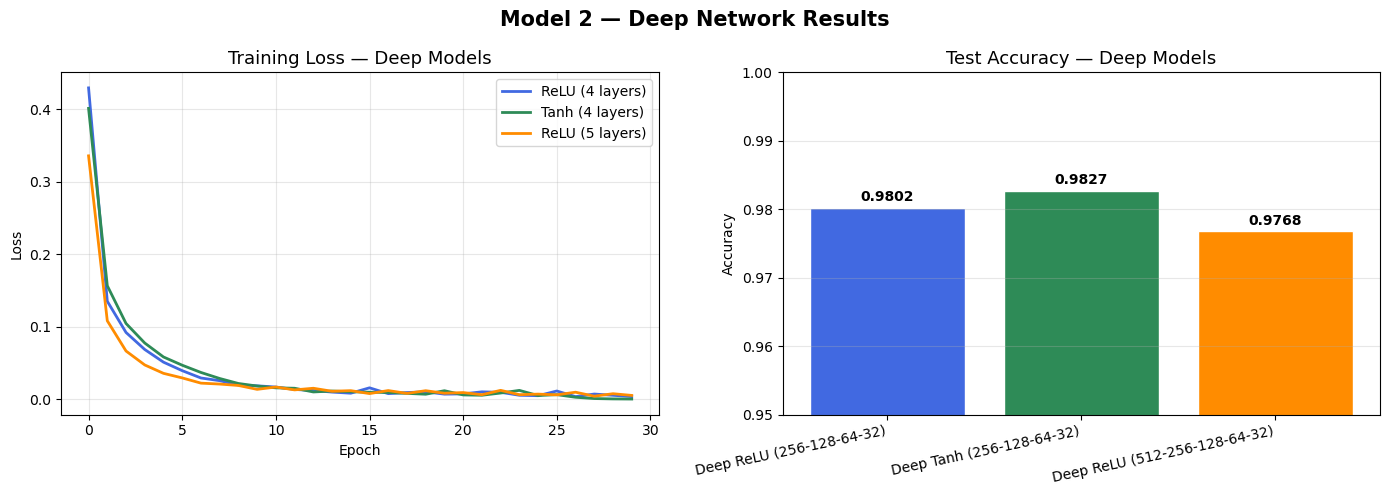

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves from sklearn loss_curve_
axes[0].plot(deep_relu.loss_curve_,   label='ReLU (4 layers)',  color='royalblue', lw=2)
axes[0].plot(deep_tanh.loss_curve_,   label='Tanh (4 layers)',  color='seagreen',  lw=2)
axes[0].plot(deep_5layer.loss_curve_, label='ReLU (5 layers)',  color='darkorange',lw=2)
axes[0].set_title('Training Loss — Deep Models', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy bar chart
names_d = list(deep_results.keys())
accs_d  = list(deep_results.values())
colors_d = ['royalblue', 'seagreen', 'darkorange']
bars = axes[1].bar(names_d, accs_d, color=colors_d, edgecolor='white')
axes[1].set_ylim(0.95, 1.0)
axes[1].set_title('Test Accuracy — Deep Models', fontsize=13)
axes[1].set_ylabel('Accuracy')
for bar, acc in zip(bars, accs_d):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=12, ha='right')

plt.suptitle('Model 2 — Deep Network Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model2_results.png', dpi=100, bbox_inches='tight')
plt.show()


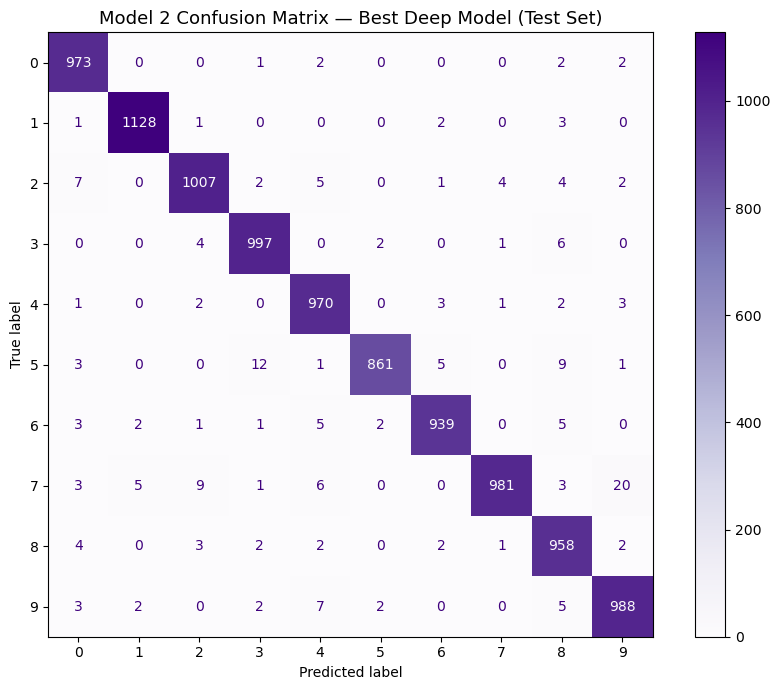


Classification Report — Model 2 (Best Deep Model):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.99      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.99      0.95      0.97      1028
           8       0.96      0.98      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [20]:
# Best deep model confusion matrix
best_deep = deep_relu  # replace with deep_5layer if it wins
y_pred_m2 = best_deep.predict(X_test)
cm2 = confusion_matrix(y_test, y_pred_m2)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=range(10)).plot(
    ax=ax, colorbar=True, cmap='Purples')
ax.set_title('Model 2 Confusion Matrix — Best Deep Model (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('model2_cm.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nClassification Report — Model 2 (Best Deep Model):")
print(classification_report(y_test, y_pred_m2, target_names=[str(i) for i in range(10)]))


## 6. Final Comparison — Model 1 vs Model 2

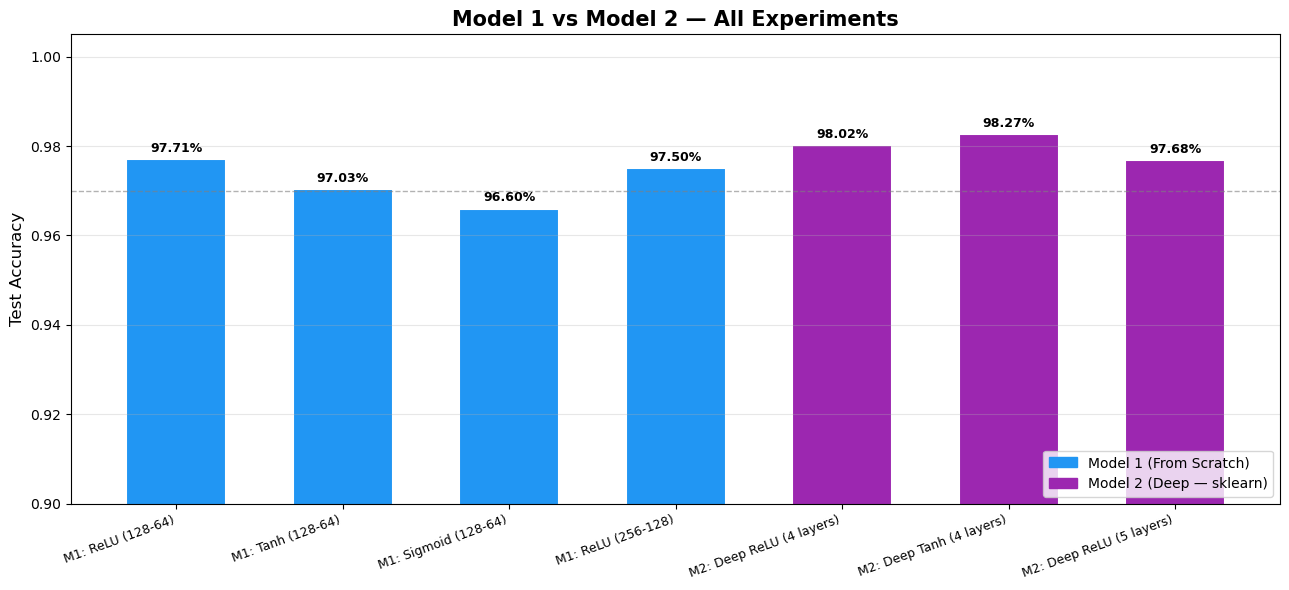


📊 Final Results Summary:
  M1: ReLU (128-64)                      → 97.71%
  M1: Tanh (128-64)                      → 97.03%
  M1: Sigmoid (128-64)                   → 96.60%
  M1: ReLU (256-128)                     → 97.50%
  M2: Deep ReLU (4 layers)               → 98.02%
  M2: Deep Tanh (4 layers)               → 98.27%
  M2: Deep ReLU (5 layers)               → 97.68%

🏆 Best overall: M2: Deep Tanh (4 layers)  →  98.27%


In [21]:
# Collect best results
all_models = {
    'M1: ReLU (128-64)':          experiment_results.get('ReLU (128-64)', 0),
    'M1: Tanh (128-64)':          experiment_results.get('Tanh (128-64)', 0),
    'M1: Sigmoid (128-64)':       experiment_results.get('Sigmoid (128-64)', 0),
    'M1: ReLU (256-128)':         experiment_results.get('ReLU (256-128)', 0),
    'M2: Deep ReLU (4 layers)':   deep_results.get('Deep ReLU (256-128-64-32)', 0),
    'M2: Deep Tanh (4 layers)':   deep_results.get('Deep Tanh (256-128-64-32)', 0),
    'M2: Deep ReLU (5 layers)':   deep_results.get('Deep ReLU (512-256-128-64-32)', 0),
}

fig, ax = plt.subplots(figsize=(13, 6))
names_all = list(all_models.keys())
accs_all  = list(all_models.values())
palette   = ['#2196F3' if n.startswith('M1') else '#9C27B0' for n in names_all]

bars = ax.bar(names_all, accs_all, color=palette, edgecolor='white', linewidth=1.5, width=0.6)
ax.set_ylim(0.90, 1.005)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Model 1 vs Model 2 — All Experiments', fontsize=15, fontweight='bold')
for bar, acc in zip(bars, accs_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(y=0.97, color='gray', lw=1, ls='--', alpha=0.6, label='97% baseline')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right', fontsize=9)

# Colour legend
import matplotlib.patches as mpatches
m1_patch = mpatches.Patch(color='#2196F3', label='Model 1 (From Scratch)')
m2_patch = mpatches.Patch(color='#9C27B0', label='Model 2 (Deep — sklearn)')
ax.legend(handles=[m1_patch, m2_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 Final Results Summary:")
print("=" * 55)
for n, a in zip(names_all, accs_all):
    print(f"  {n:<38} → {a*100:.2f}%")
best_overall = names_all[np.argmax(accs_all)]
print(f"\n🏆 Best overall: {best_overall}  →  {max(accs_all)*100:.2f}%")


## 7. Visualising Predictions (Best Model)

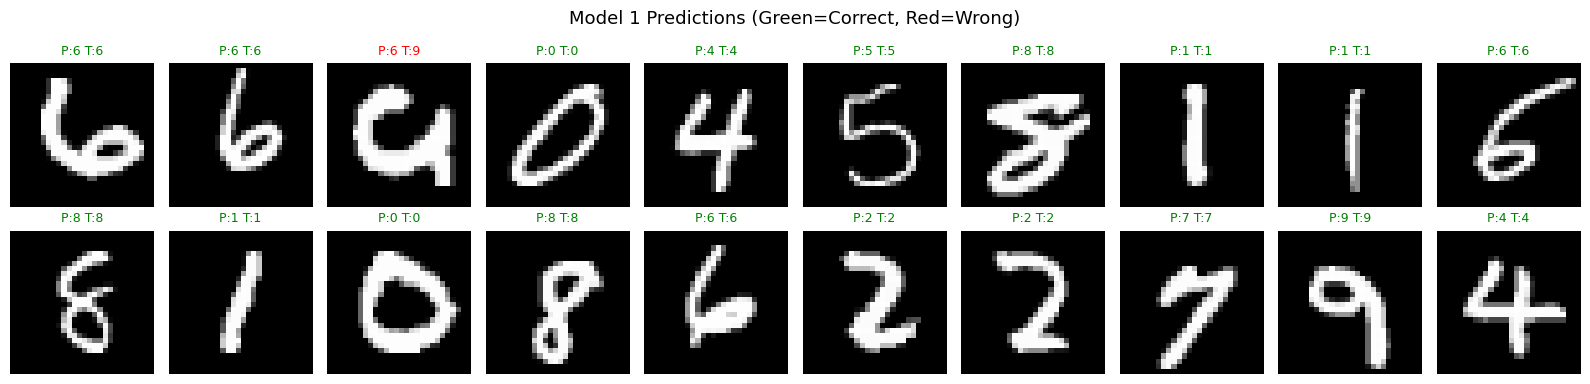

In [22]:
# Show 20 test images with their predicted vs true labels
np.random.seed(10)
indices = np.random.choice(len(X_test), 20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i, idx in enumerate(indices):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_test_raw[idx], cmap='gray')
    pred_m1 = mlp_relu.predict(X_test[idx:idx+1])[0]
    true_l  = y_test[idx]
    color   = 'green' if pred_m1 == true_l else 'red'
    ax.set_title(f'P:{pred_m1} T:{true_l}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Model 1 Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('predictions.png', dpi=100, bbox_inches='tight')
plt.show()
